## 0. Imports & Setup

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb

torch.manual_seed(42)
np.random.seed(42)

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/DATA/ghana_master.csv'
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/DATA/'

def section(t):    print(f"\n{'─'*60}\n  {t}\n{'─'*60}")
def subsection(t): print(f"\n  ── {t}")



## 1. Load Data & Define Splits
**Section 4:** Train = Jan 2011–Jan 2025 (169 months), Test = Feb 2025–Jan 2026 (12 months)

In [30]:
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.sort_index()

# Cast month dummies to int
month_cols = [c for c in df.columns if c.startswith('month_')]
df[month_cols] = df[month_cols].astype(int)

TARGET   = 'inflation'
TEST_SIZE = 12   # Feb 2025 – Jan 2026 as per Section 4

# ── Exogenous variables (Section 3.2) ────────────────────────
EXOG_COLS = ['exchange_rate', 'food_index', 'housing_index']

# ── ML feature set (Section 3.4) ────────────────────────────
# All engineered features except the raw target and log-transformed target
FEATURE_COLS = [c for c in df.columns if c not in [TARGET, 'inflation_log']]

# ── LSTM feature subset (Section 3.5.4 — 10 features) ───────
LSTM_FEATURES = [
    'inflation_lag1', 'inflation_lag2', 'inflation_lag3',
    'inflation_lag6', 'inflation_lag12',
    'inflation_ma3',  'inflation_ma6',
    'exchange_rate',  'food_index', 'housing_index'
]

train_df = df.iloc[:-TEST_SIZE].copy()
test_df  = df.iloc[-TEST_SIZE:].copy()

# Rolling-origin CV start index = 80% of total n (Section 3.5.6 eq 3.5.32)
MIN_TRAIN = int(len(df) * 0.80)

section('DATA SUMMARY')
print(f'  Total rows     : {len(df)}')
print(f'  Full period    : {df.index[0].strftime("%b %Y")} → {df.index[-1].strftime("%b %Y")}')
print(f'  Train period   : {train_df.index[0].strftime("%b %Y")} → {train_df.index[-1].strftime("%b %Y")}  ({len(train_df)} months)')
print(f'  Test period    : {test_df.index[0].strftime("%b %Y")} → {test_df.index[-1].strftime("%b %Y")}  ({len(test_df)} months)')
print(f'  Rolling CV start index: {MIN_TRAIN}')
print(f'  ML features    : {len(FEATURE_COLS)}')
print(f'  LSTM features  : {len(LSTM_FEATURES)}')


────────────────────────────────────────────────────────────
  DATA SUMMARY
────────────────────────────────────────────────────────────
  Total rows     : 181
  Full period    : Jan 2011 → Jan 2026
  Train period   : Jan 2011 → Jan 2025  (169 months)
  Test period    : Feb 2025 → Jan 2026  (12 months)
  Rolling CV start index: 144
  ML features    : 32
  LSTM features  : 10


## 2. Evaluation Metrics
**Section 3.5.7:** RMSE, MAE, MAPE with ε = 1e-8 (eq 3.5.33–3.5.35)

In [31]:
EPS = 1e-8   # Section 3.5.7 eq 3.5.35

def compute_metrics(actual, predicted, model_name='Model'):
    """RMSE, MAE, MAPE exactly as defined in Section 3.5.7."""
    actual    = np.array(actual)
    predicted = np.array(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    # eq 3.5.35: MAPE with epsilon floor
    mape = np.mean(np.abs((actual - predicted) / (actual + EPS))) * 100
    print(f"{'='*52}")
    print(f"  {model_name}")
    print(f"{'='*52}")
    print(f"  RMSE : {rmse:.4f}  (percentage points)")
    print(f"  MAE  : {mae:.4f}  (percentage points)")
    print(f"  MAPE : {mape:.4f}%")
    return {'Model': model_name, 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'MAPE': round(mape,4)}

all_results = []   # collects every model's metrics
print('Metrics function ready. EPS =', EPS)

Metrics function ready. EPS = 1e-08


---
## 3. SARIMAX
**Section 3.5.1:** Order (1,1,1)(1,1,1,12) selected via BIC (eq 3.5.2).
Exogenous: exchange_rate, food_index, housing_index.
Back-transform: ŷ_t = exp(ŷ_log,t) − 1 (eq 3.5.4) only if log series used;
since untransformed series is used (Section 4.1.3), no back-transform needed.

In [32]:
section('SARIMAX — BIC ORDER SELECTION')

# Grid search over p,q,P,Q with d=1,D=1,s=12 — select by BIC (eq 3.5.2)
best_bic   = np.inf
best_order = (1,1,1)
best_sorder= (1,1,1,12)

print(f"  {'Order':<22} {'Seasonal':<22} {'BIC':>10}")
print(f"  {'─'*58}")

for p in [1, 2]:
    for q in [1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(
                        train_df[TARGET],
                        exog=train_df[EXOG_COLS],
                        order=(p,1,q),
                        seasonal_order=(P,1,Q,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False)
                    bic = m.bic
                    print(f"  ({p},1,{q})                ({P},1,{Q},12)              {bic:>10.2f}")
                    if bic < best_bic:
                        best_bic    = bic
                        best_order  = (p,1,q)
                        best_sorder = (P,1,Q,12)
                except:
                    pass

print(f"\n  Best order  : {best_order}")
print(f"  Best seasonal: {best_sorder}")
print(f"  Best BIC     : {best_bic:.2f}")


────────────────────────────────────────────────────────────
  SARIMAX — BIC ORDER SELECTION
────────────────────────────────────────────────────────────
  Order                  Seasonal                      BIC
  ──────────────────────────────────────────────────────────
  (1,1,1)                (0,1,0,12)                  595.49
  (1,1,1)                (0,1,1,12)                  531.17
  (1,1,1)                (1,1,0,12)                  530.68
  (1,1,1)                (1,1,1,12)                  523.68
  (1,1,2)                (0,1,0,12)                  595.30
  (1,1,2)                (0,1,1,12)                  531.70
  (1,1,2)                (1,1,0,12)                  535.56
  (1,1,2)                (1,1,1,12)                  520.81
  (2,1,1)                (0,1,0,12)                  598.10
  (2,1,1)                (0,1,1,12)                  534.11
  (2,1,1)                (1,1,0,12)                  528.59
  (2,1,1)                (1,1,1,12)                  524.19
  (2,

In [33]:
section('SARIMAX — FIT ON TRAINING SET')

sarimax_model = SARIMAX(
    train_df[TARGET],
    exog=train_df[EXOG_COLS],
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())


────────────────────────────────────────────────────────────
  SARIMAX — FIT ON TRAINING SET
────────────────────────────────────────────────────────────
                                      SARIMAX Results                                       
Dep. Variable:                            inflation   No. Observations:                  169
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -238.134
Date:                              Fri, 15 May 2026   AIC                            494.267
Time:                                      11:52:35   BIC                            520.806
Sample:                                  01-01-2011   HQIC                           505.052
                                       - 01-01-2025                                         
Covariance Type:                                opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------


────────────────────────────────────────────────────────────
  SARIMAX — LJUNG-BOX RESIDUAL DIAGNOSTICS (eq 3.5.3)
────────────────────────────────────────────────────────────
      lb_stat  lb_pvalue
6   14.378371   0.025684
12  36.406270   0.000279
18  42.619987   0.000905
24  49.425110   0.001675
  Lag  6: p=0.0257 → FAIL — autocorrelation remains
  Lag 12: p=0.0003 → FAIL — autocorrelation remains
  Lag 18: p=0.0009 → FAIL — autocorrelation remains
  Lag 24: p=0.0017 → FAIL — autocorrelation remains


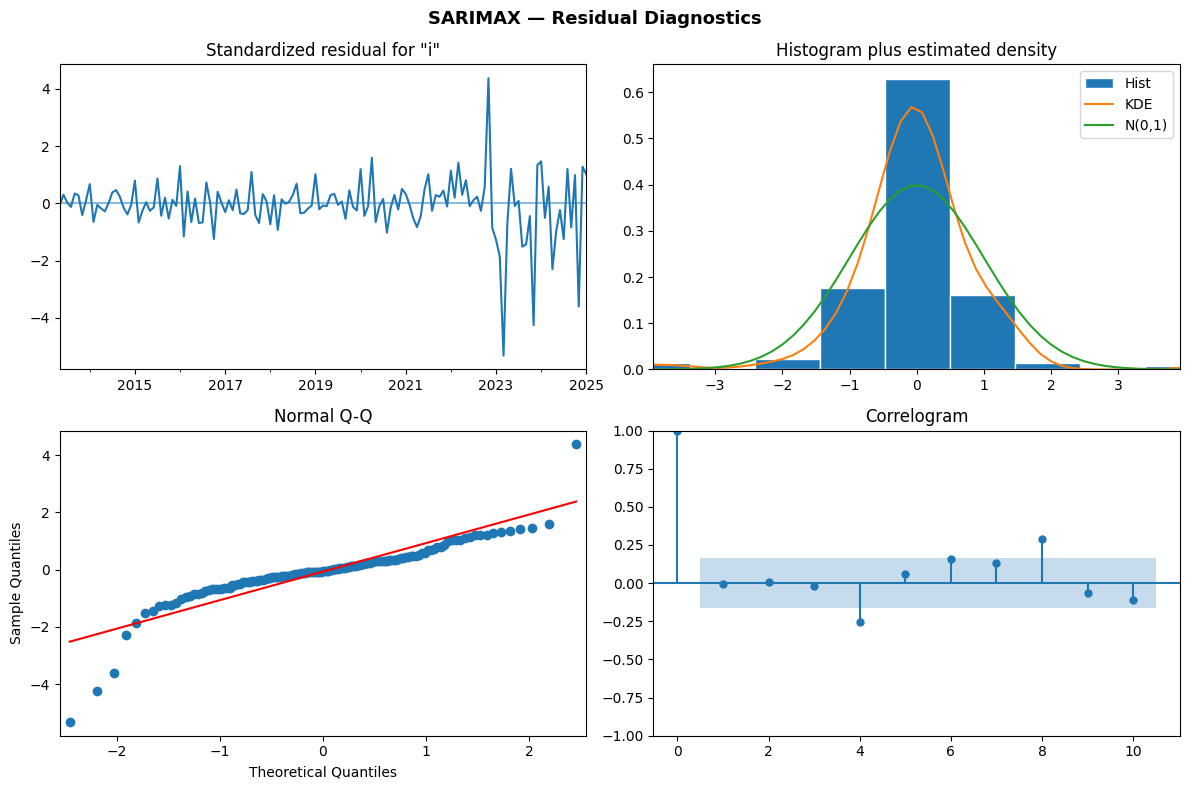

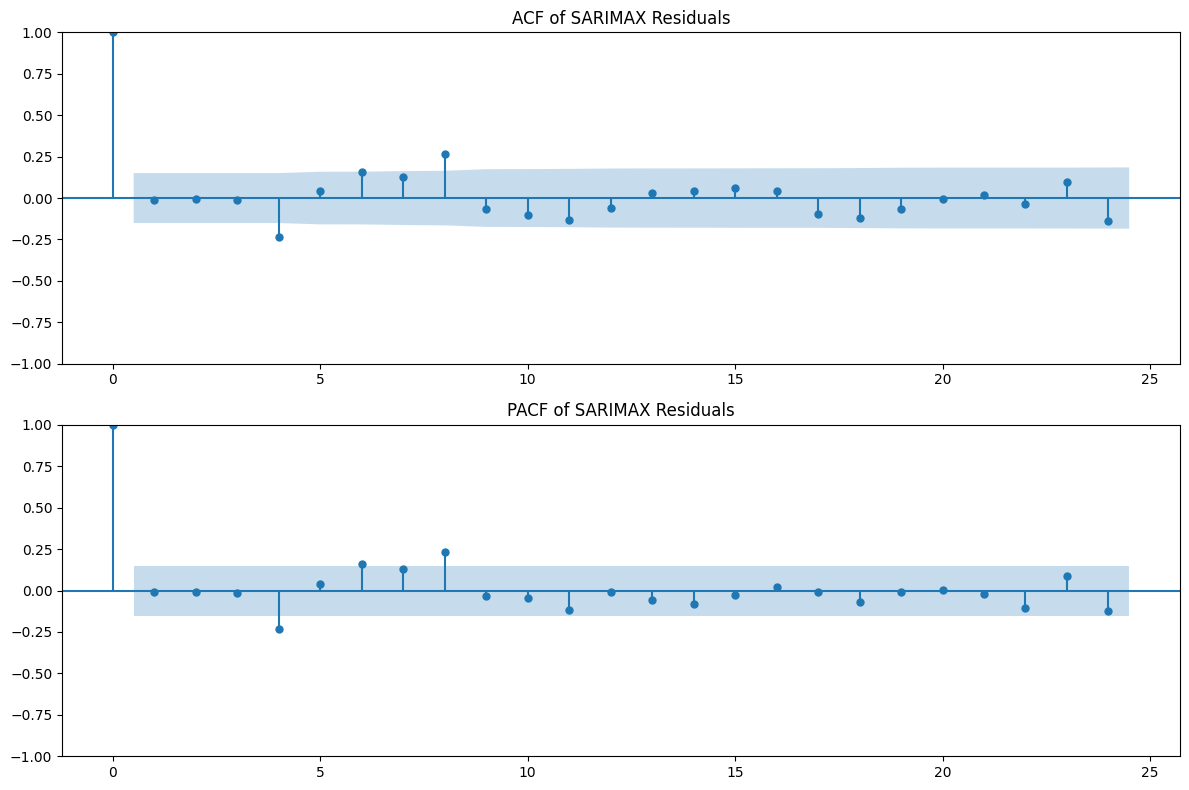

In [34]:
# Ljung-Box test (eq 3.5.3) — p > 0.05 confirms white-noise residuals
section('SARIMAX — LJUNG-BOX RESIDUAL DIAGNOSTICS (eq 3.5.3)')

residuals = sarimax_fit.resid
lb = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)
print(lb)
for lag in [6, 12, 18, 24]:
    p = lb.loc[lag, 'lb_pvalue']
    verdict = 'PASS — white noise' if p > 0.05 else 'FAIL — autocorrelation remains'
    print(f'  Lag {lag:>2d}: p={p:.4f} → {verdict}')

# Full diagnostic plot
fig = sarimax_fit.plot_diagnostics(figsize=(12, 8))
fig.suptitle('SARIMAX — Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'sarimax_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ACF / PACF of residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(residuals, lags=24, ax=axes[0], title='ACF of SARIMAX Residuals')
plot_pacf(residuals, lags=24, ax=axes[1], title='PACF of SARIMAX Residuals')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'sarimax_resid_acf.png', dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────
  SARIMAX — STATIC TEST-SET FORECAST
────────────────────────────────────────────────────────────
  SARIMAX Static Test
  RMSE : 5.5719  (percentage points)
  MAE  : 4.8459  (percentage points)
  MAPE : 65.6978%


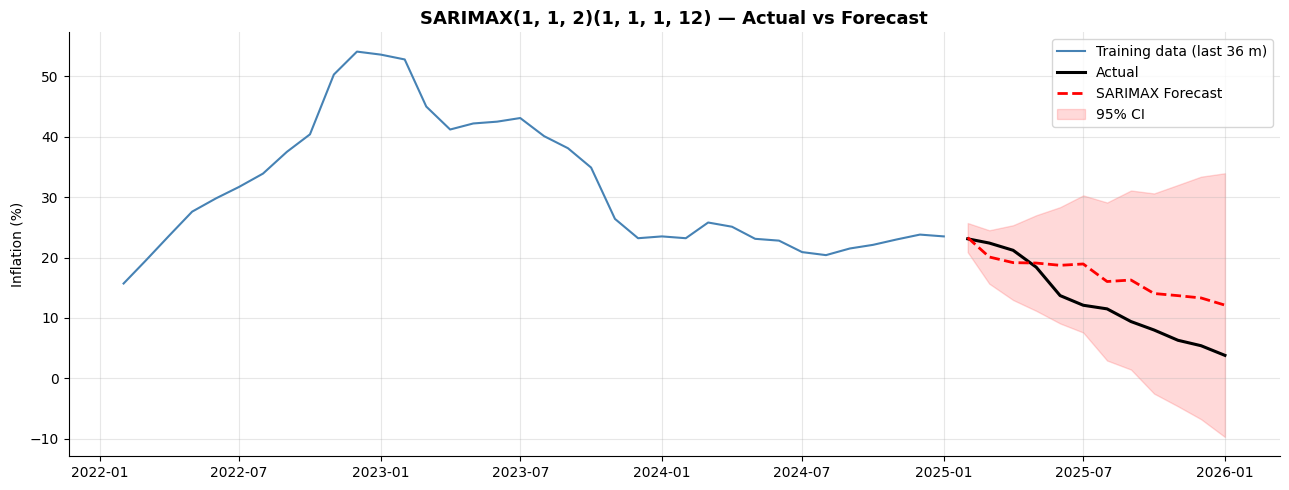

In [35]:
# Static 12-month test-set forecast
section('SARIMAX — STATIC TEST-SET FORECAST')

forecast_obj = sarimax_fit.get_forecast(steps=TEST_SIZE, exog=test_df[EXOG_COLS])
sarimax_forecast = forecast_obj.predicted_mean
sarimax_ci       = forecast_obj.conf_int()

sarimax_res = compute_metrics(test_df[TARGET], sarimax_forecast, 'SARIMAX Static Test')
all_results.append(sarimax_res)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_df[TARGET].iloc[-36:], color='steelblue', linewidth=1.5, label='Training data (last 36 m)')
ax.plot(test_df[TARGET],             color='black',     linewidth=2.2, label='Actual')
ax.plot(sarimax_forecast,            color='red',       linewidth=2, linestyle='--', label='SARIMAX Forecast')
ax.fill_between(sarimax_ci.index, sarimax_ci.iloc[:,0], sarimax_ci.iloc[:,1],
                alpha=0.15, color='red', label='95% CI')
ax.set_title(f'SARIMAX{best_order}{best_sorder} — Actual vs Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Inflation (%)')
ax.legend(); ax.grid(alpha=0.3)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
#plt.savefig(SAVE_PATH + 'sarimax_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────
  SARIMAX — ROLLING-ORIGIN CROSS-VALIDATION (Section 3.5.6)
────────────────────────────────────────────────────────────
  Step  1 (Jan 2023): Actual= 53.60  Pred= 55.58
  Step  2 (Feb 2023): Actual= 52.80  Pred= 54.91
  Step  3 (Mar 2023): Actual= 45.00  Pred= 50.48
  Step  4 (Apr 2023): Actual= 41.20  Pred= 44.32
  Step  5 (May 2023): Actual= 42.20  Pred= 42.63
  Step  6 (Jun 2023): Actual= 42.50  Pred= 39.97
  Step  7 (Jul 2023): Actual= 43.10  Pred= 42.49
  Step  8 (Aug 2023): Actual= 40.10  Pred= 37.59
  Step  9 (Sep 2023): Actual= 38.10  Pred= 40.64
  Step 10 (Oct 2023): Actual= 34.90  Pred= 33.23
  Step 11 (Nov 2023): Actual= 26.40  Pred= 33.77
  Step 12 (Dec 2023): Actual= 23.20  Pred= 19.91
  Step 13 (Jan 2024): Actual= 23.50  Pred= 18.22
  Step 14 (Feb 2024): Actual= 23.20  Pred= 21.58
  Step 15 (Mar 2024): Actual= 25.80  Pred= 24.57
  Step 16 (Apr 2024): Actual= 25.10  Pred= 28.78
  Step 17 (May 2024): Actual= 23.

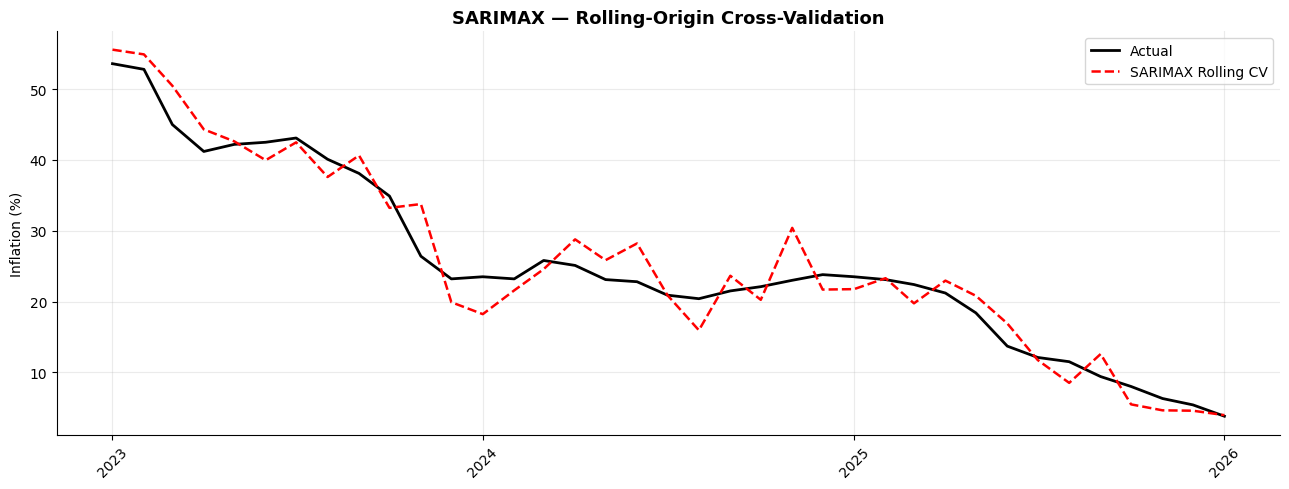

In [36]:
# Rolling-origin CV (Section 3.5.6) — one-step-ahead, expanding window
section('SARIMAX — ROLLING-ORIGIN CROSS-VALIDATION (Section 3.5.6)')

sarimax_cv_actual, sarimax_cv_pred, sarimax_cv_dates = [], [], []

for i in range(MIN_TRAIN, len(df)):
    tr = df.iloc[:i]
    te = df.iloc[i:i+1]
    try:
        m = SARIMAX(
            tr[TARGET], exog=tr[EXOG_COLS],
            order=best_order, seasonal_order=best_sorder,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        p = m.forecast(steps=1, exog=te[EXOG_COLS]).values[0]
        sarimax_cv_actual.append(te[TARGET].values[0])
        sarimax_cv_pred.append(p)
        sarimax_cv_dates.append(te.index[0])
        step = i - MIN_TRAIN + 1
        print(f'  Step {step:>2d} ({te.index[0].strftime("%b %Y")}): '
              f'Actual={sarimax_cv_actual[-1]:6.2f}  Pred={p:6.2f}')
    except Exception as e:
        print(f'  Step {i-MIN_TRAIN+1}: FAILED — {e}')

sarimax_cv_res = compute_metrics(sarimax_cv_actual, sarimax_cv_pred, 'SARIMAX (Rolling CV)')
all_results.append(sarimax_cv_res)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sarimax_cv_dates, sarimax_cv_actual, color='black', linewidth=2, label='Actual')
ax.plot(sarimax_cv_dates, sarimax_cv_pred,   color='red',   linewidth=1.8, linestyle='--', label='SARIMAX Rolling CV')
ax.set_title('SARIMAX — Rolling-Origin Cross-Validation', fontsize=13, fontweight='bold')
ax.set_ylabel('Inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'sarimax_rolling_cv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Random Forest
**Section 3.5.2:** Ensemble of decision trees, MSE splitting criterion (eq 3.5.6),
feature importance via MDI (eq 3.5.8). Hyperparameters tuned via rolling-origin CV.
All 36 engineered features used as input (Section 3.5.2 paragraph 5).

In [37]:
section('RANDOM FOREST — HYPERPARAMETER TUNING (Rolling-Origin CV)')

# Tuning grid: n_estimators, max_depth, min_samples_leaf (Section 3.5.2)
rf_param_grid = {
    'n_estimators':    [200, 500],
    'max_depth':       [5, 10, None],
    'min_samples_leaf':[2, 4],
}

# Use first 80% of data for tuning (inner CV within training set)
tune_end  = int(len(df) * 0.80)
tune_start= int(tune_end * 0.80)
tune_df   = df.iloc[:tune_end].copy()

best_rf_rmse, best_rf_params = np.inf, None

print(f"  {'n_est':<6} {'max_d':<8} {'min_leaf':<10} {'RMSE':>8}")
print(f"  {'─'*38}")

for params in ParameterGrid(rf_param_grid):
    acts, ps = [], []
    for i in range(tune_start, tune_end):
        Xtr = tune_df.iloc[:i][FEATURE_COLS]
        ytr = tune_df.iloc[:i][TARGET]
        Xte = tune_df.iloc[i:i+1][FEATURE_COLS]
        yte = tune_df.iloc[i][TARGET]
        rf  = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        rf.fit(Xtr, ytr)
        ps.append(rf.predict(Xte)[0])
        acts.append(yte)
    rmse = np.sqrt(mean_squared_error(acts, ps))
    print(f"  {params['n_estimators']:<6} {str(params['max_depth']):<8} {params['min_samples_leaf']:<10} {rmse:>8.4f}")
    if rmse < best_rf_rmse:
        best_rf_rmse, best_rf_params = rmse, params

print(f"\n  Best params : {best_rf_params}  (CV RMSE={best_rf_rmse:.4f})")


────────────────────────────────────────────────────────────
  RANDOM FOREST — HYPERPARAMETER TUNING (Rolling-Origin CV)
────────────────────────────────────────────────────────────
  n_est  max_d    min_leaf       RMSE
  ──────────────────────────────────────
  200    5        2            5.3550
  500    5        2            5.3194
  200    5        4            6.9811
  500    5        4            6.9693
  200    10       2            5.3837
  500    10       2            5.3440
  200    10       4            6.9902
  500    10       4            6.9630
  200    None     2            5.3898
  500    None     2            5.3467
  200    None     4            6.9902
  500    None     4            6.9630

  Best params : {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 500}  (CV RMSE=5.3194)


In [38]:
section('RANDOM FOREST — ROLLING-ORIGIN CROSS-VALIDATION (full 20% window)')

rf_cv_actual, rf_cv_pred, rf_cv_dates = [], [], []

for i in range(MIN_TRAIN, len(df)):
    Xtr = df.iloc[:i][FEATURE_COLS]
    ytr = df.iloc[:i][TARGET]
    Xte = df.iloc[i:i+1][FEATURE_COLS]
    yte = df.iloc[i][TARGET]
    rf  = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    p   = rf.predict(Xte)[0]
    rf_cv_actual.append(yte)
    rf_cv_pred.append(p)
    rf_cv_dates.append(df.index[i])
    step = i - MIN_TRAIN + 1
    print(f'  Step {step:>2d} ({df.index[i].strftime("%b %Y")}): Actual={yte:6.2f}  Pred={p:6.2f}')

rf_cv_res = compute_metrics(rf_cv_actual, rf_cv_pred, 'Random Forest (Rolling CV)')
all_results.append(rf_cv_res)


────────────────────────────────────────────────────────────
  RANDOM FOREST — ROLLING-ORIGIN CROSS-VALIDATION (full 20% window)
────────────────────────────────────────────────────────────
  Step  1 (Jan 2023): Actual= 53.60  Pred= 46.04
  Step  2 (Feb 2023): Actual= 52.80  Pred= 49.35
  Step  3 (Mar 2023): Actual= 45.00  Pred= 51.29
  Step  4 (Apr 2023): Actual= 41.20  Pred= 50.41
  Step  5 (May 2023): Actual= 42.20  Pred= 46.37
  Step  6 (Jun 2023): Actual= 42.50  Pred= 44.33
  Step  7 (Jul 2023): Actual= 43.10  Pred= 43.99
  Step  8 (Aug 2023): Actual= 40.10  Pred= 44.40
  Step  9 (Sep 2023): Actual= 38.10  Pred= 42.81
  Step 10 (Oct 2023): Actual= 34.90  Pred= 40.20
  Step 11 (Nov 2023): Actual= 26.40  Pred= 38.25
  Step 12 (Dec 2023): Actual= 23.20  Pred= 33.72
  Step 13 (Jan 2024): Actual= 23.50  Pred= 27.79
  Step 14 (Feb 2024): Actual= 23.20  Pred= 26.78
  Step 15 (Mar 2024): Actual= 25.80  Pred= 24.12
  Step 16 (Apr 2024): Actual= 25.10  Pred= 27.13
  Step 17 (May 2024): Act

  Random Forest Static Test
  RMSE : 3.7649  (percentage points)
  MAE  : 3.1485  (percentage points)
  MAPE : 37.5864%


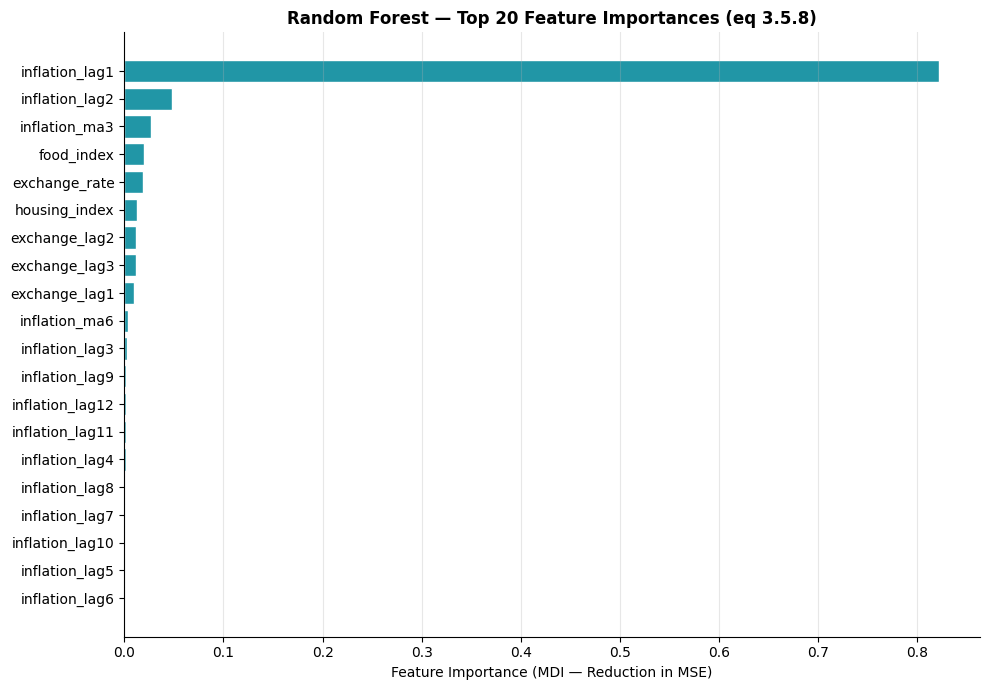

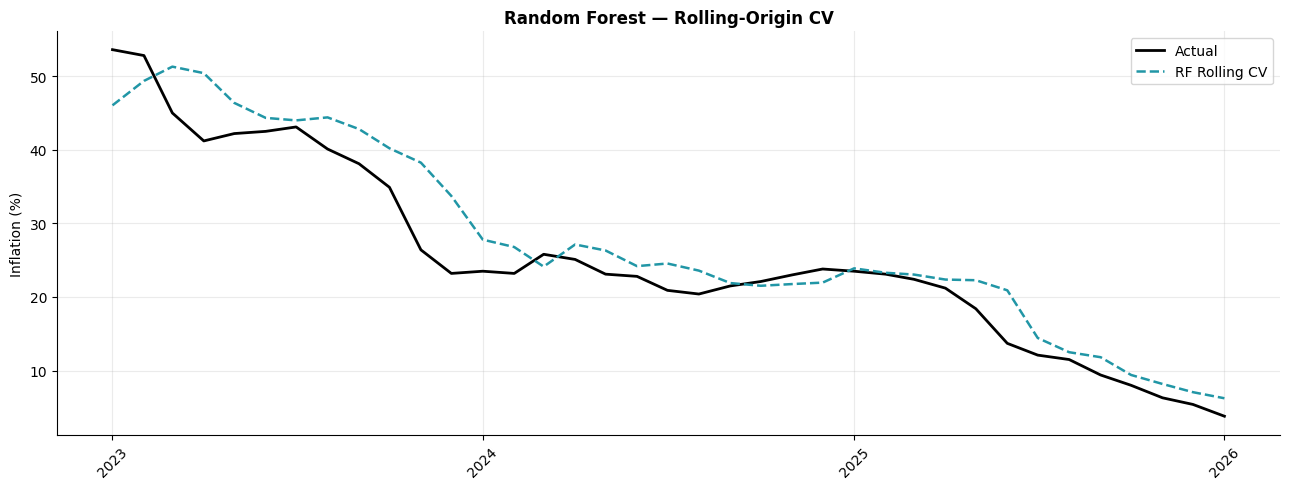


Top 10 features (RF):
inflation_lag1    0.822182
inflation_lag2    0.048147
inflation_ma3     0.026633
food_index        0.019909
exchange_rate     0.019011
housing_index     0.012936
exchange_lag2     0.012115
exchange_lag3     0.011428
exchange_lag1     0.009441
inflation_ma6     0.003899


In [39]:
# Fit final RF on full training set for feature importance (eq 3.5.8) and test-set forecast
rf_final = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_final.fit(train_df[FEATURE_COLS], train_df[TARGET])
rf_test_pred = rf_final.predict(test_df[FEATURE_COLS])

rf_test_res = compute_metrics(test_df[TARGET], rf_test_pred, 'Random Forest Static Test')
all_results.append(rf_test_res)

# Feature importance plot (eq 3.5.8 — MDI reduction in MSE)
importance_rf = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20_rf = importance_rf.head(20)

# ── Plot 1: Feature Importance ───────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 7))
ax1.barh(top20_rf.index[::-1], top20_rf.values[::-1], color='#2196A6', edgecolor='white')
ax1.set_xlabel('Feature Importance (MDI — Reduction in MSE)')
ax1.set_title('Random Forest — Top 20 Feature Importances (eq 3.5.8)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for s in ['top', 'right']: ax1.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Rolling-Origin CV ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))
ax2.plot(rf_cv_dates, rf_cv_actual, color='black',   linewidth=2,   label='Actual')
ax2.plot(rf_cv_dates, rf_cv_pred,   color='#2196A6', linewidth=1.8, linestyle='--', label='RF Rolling CV')
ax2.set_title('Random Forest — Rolling-Origin CV', fontweight='bold')
ax2.set_ylabel('Inflation (%)')
ax2.legend()
ax2.grid(alpha=0.25)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
for s in ['top', 'right']: ax2.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'rf_rolling_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features (RF):')
print(importance_rf.head(10).to_string())

---
## 5. XGBoost
**Section 3.5.3:** XGBoost predicts **month-on-month changes** Δy_t = y_t − y_{t-1} (eq 3.5.9),
then levels are recovered via cumulative summation from the last training level (eq 3.5.10).
7 momentum features added on top of the 36 base features (Table 3.3).
Feature importance via gain criterion (eq 3.5.19).

In [40]:
section('XGBOOST — BUILD MOMENTUM FEATURES (Table 3.3)')

df_xgb = df.copy()

# Table 3.3 momentum features (eq 3.5.9)
df_xgb['diff_1']       = df_xgb[TARGET].diff(1)         # Δy_t
df_xgb['diff_2']       = df_xgb[TARGET].diff(2)
df_xgb['diff_3']       = df_xgb[TARGET].diff(3)
df_xgb['acceleration'] = df_xgb['diff_1'].diff(1)       # second derivative
df_xgb['diff_3m_avg']  = df_xgb['diff_1'].rolling(3).mean()
df_xgb['diff_6m_avg']  = df_xgb['diff_1'].rolling(6).mean()
df_xgb['diff_3m_std']  = df_xgb['diff_1'].rolling(3).std()

df_xgb = df_xgb.dropna()

MOMENTUM_COLS = ['diff_1','diff_2','diff_3','acceleration','diff_3m_avg','diff_6m_avg','diff_3m_std']
XGB_FEATURES  = FEATURE_COLS + MOMENTUM_COLS

# XGBoost TARGET is the month-on-month change (eq 3.5.9)
df_xgb['delta_y'] = df_xgb[TARGET].diff(1)
df_xgb = df_xgb.dropna()

print(f'  XGBoost feature count : {len(XGB_FEATURES)} ({len(FEATURE_COLS)} base + {len(MOMENTUM_COLS)} momentum)')
print(f'  Rows after dropna     : {len(df_xgb)}')


────────────────────────────────────────────────────────────
  XGBOOST — BUILD MOMENTUM FEATURES (Table 3.3)
────────────────────────────────────────────────────────────
  XGBoost feature count : 39 (32 base + 7 momentum)
  Rows after dropna     : 174


In [41]:
section('XGBOOST — HYPERPARAMETER TUNING (Rolling-Origin CV)')

xgb_param_grid = {
    'n_estimators':     [300, 500],
    'max_depth':        [3, 5],
    'learning_rate':    [0.03, 0.05],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
    'reg_lambda':       [1, 5],    # λ in eq 3.5.14
    'gamma':            [0, 0.1],  # γ in eq 3.5.14
}

tune_end_xgb  = int(len(df_xgb) * 0.80)
tune_start_xgb= int(tune_end_xgb * 0.80)
tune_df_xgb   = df_xgb.iloc[:tune_end_xgb].copy()

best_xgb_rmse, best_xgb_params = np.inf, None

print(f"  {'lr':<6} {'d':<4} {'n':<5} {'lam':<5} {'gam':<5} {'RMSE':>8}")
print(f"  {'─'*40}")

for params in ParameterGrid(xgb_param_grid):
    acts, ps = [], []
    last_train_level = None
    for i in range(tune_start_xgb, tune_end_xgb):
        Xtr = tune_df_xgb.iloc[:i][XGB_FEATURES]
        ytr = tune_df_xgb.iloc[:i]['delta_y']      # train on changes
        Xte = tune_df_xgb.iloc[i:i+1][XGB_FEATURES]
        true_level = tune_df_xgb.iloc[i][TARGET]
        last_level  = tune_df_xgb.iloc[i-1][TARGET]
        m = xgb.XGBRegressor(**params, objective='reg:squarederror',
                              random_state=42, verbosity=0)
        m.fit(Xtr, ytr)
        delta_pred = m.predict(Xte)[0]
        level_pred = last_level + delta_pred         # eq 3.5.10 (one step)
        ps.append(level_pred)
        acts.append(true_level)
    rmse = np.sqrt(mean_squared_error(acts, ps))
    print(f"  {params['learning_rate']:<6} {params['max_depth']:<4} {params['n_estimators']:<5} "
          f"{params['reg_lambda']:<5} {params['gamma']:<5} {rmse:>8.4f}")
    if rmse < best_xgb_rmse:
        best_xgb_rmse, best_xgb_params = rmse, params

print(f"\n  Best XGB params : {best_xgb_params}  (CV RMSE={best_xgb_rmse:.4f})")


────────────────────────────────────────────────────────────
  XGBOOST — HYPERPARAMETER TUNING (Rolling-Origin CV)
────────────────────────────────────────────────────────────
  lr     d    n     lam   gam       RMSE
  ────────────────────────────────────────
  0.03   3    300   1     0       1.2567
  0.03   3    300   5     0       1.2982
  0.03   3    500   1     0       1.2456
  0.03   3    500   5     0       1.2293
  0.03   5    300   1     0       1.2729
  0.03   5    300   5     0       1.3017
  0.03   5    500   1     0       1.2580
  0.03   5    500   5     0       1.2347
  0.05   3    300   1     0       1.2264
  0.05   3    300   5     0       1.2426
  0.05   3    500   1     0       1.2268
  0.05   3    500   5     0       1.2103
  0.05   5    300   1     0       1.2313
  0.05   5    300   5     0       1.2408
  0.05   5    500   1     0       1.2300
  0.05   5    500   5     0       1.2113
  0.03   3    300   1     0.1     1.3073
  0.03   3    300   5     0.1     1.2878
 

In [42]:
section('XGBOOST — ROLLING-ORIGIN CROSS-VALIDATION')

xgb_min_train = int(len(df_xgb) * 0.80)
xgb_cv_actual, xgb_cv_pred, xgb_cv_dates = [], [], []

for i in range(xgb_min_train, len(df_xgb)):
    Xtr = df_xgb.iloc[:i][XGB_FEATURES]
    ytr = df_xgb.iloc[:i]['delta_y']
    Xte = df_xgb.iloc[i:i+1][XGB_FEATURES]
    true_level = df_xgb.iloc[i][TARGET]
    last_level  = df_xgb.iloc[i-1][TARGET]

    m = xgb.XGBRegressor(**best_xgb_params, objective='reg:squarederror',
                          random_state=42, verbosity=0)
    m.fit(Xtr, ytr)
    delta_pred = m.predict(Xte)[0]
    level_pred = last_level + delta_pred            # eq 3.5.10

    xgb_cv_actual.append(true_level)
    xgb_cv_pred.append(level_pred)
    xgb_cv_dates.append(df_xgb.index[i])
    step = i - xgb_min_train + 1
    print(f'  Step {step:>2d} ({df_xgb.index[i].strftime("%b %Y")}): '
          f'Actual={true_level:6.2f}  Pred={level_pred:6.2f}')

xgb_cv_res = compute_metrics(xgb_cv_actual, xgb_cv_pred, 'XGBoost (Rolling CV)')
all_results.append(xgb_cv_res)


────────────────────────────────────────────────────────────
  XGBOOST — ROLLING-ORIGIN CROSS-VALIDATION
────────────────────────────────────────────────────────────
  Step  1 (Mar 2023): Actual= 45.00  Pred= 50.78
  Step  2 (Apr 2023): Actual= 41.20  Pred= 41.48
  Step  3 (May 2023): Actual= 42.20  Pred= 41.45
  Step  4 (Jun 2023): Actual= 42.50  Pred= 41.98
  Step  5 (Jul 2023): Actual= 43.10  Pred= 43.07
  Step  6 (Aug 2023): Actual= 40.10  Pred= 38.83
  Step  7 (Sep 2023): Actual= 38.10  Pred= 37.70
  Step  8 (Oct 2023): Actual= 34.90  Pred= 35.74
  Step  9 (Nov 2023): Actual= 26.40  Pred= 32.03
  Step 10 (Dec 2023): Actual= 23.20  Pred= 23.44
  Step 11 (Jan 2024): Actual= 23.50  Pred= 23.62
  Step 12 (Feb 2024): Actual= 23.20  Pred= 23.56
  Step 13 (Mar 2024): Actual= 25.80  Pred= 25.37
  Step 14 (Apr 2024): Actual= 25.10  Pred= 25.54
  Step 15 (May 2024): Actual= 23.10  Pred= 26.71
  Step 16 (Jun 2024): Actual= 22.80  Pred= 23.41
  Step 17 (Jul 2024): Actual= 20.90  Pred= 20.88


  XGBoost Static Test
  RMSE : 2.3105  (percentage points)
  MAE  : 1.8988  (percentage points)
  MAPE : 25.4610%


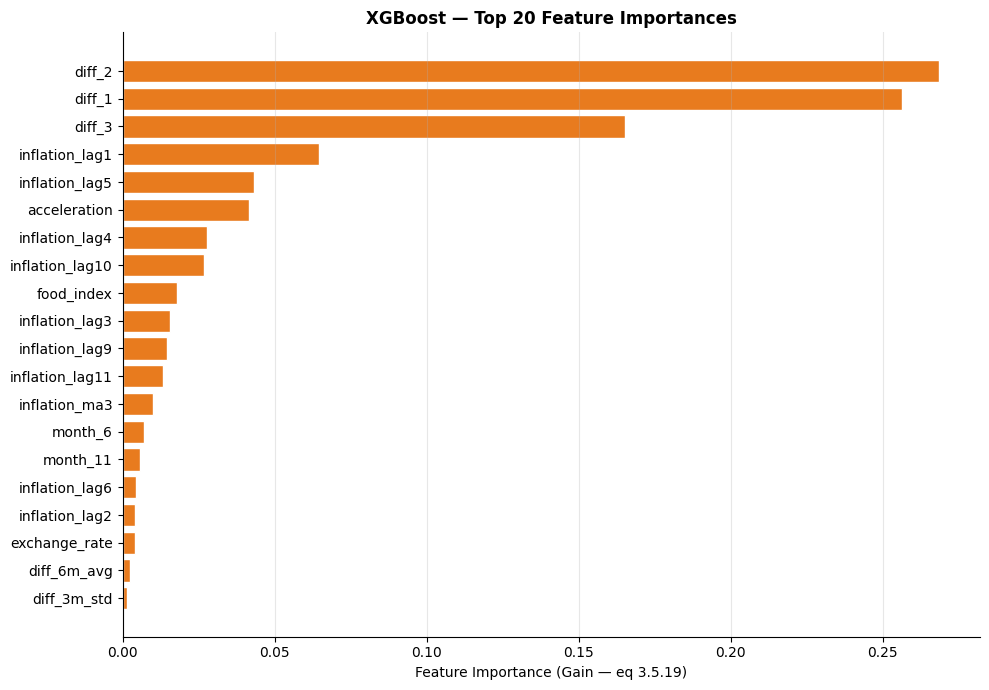

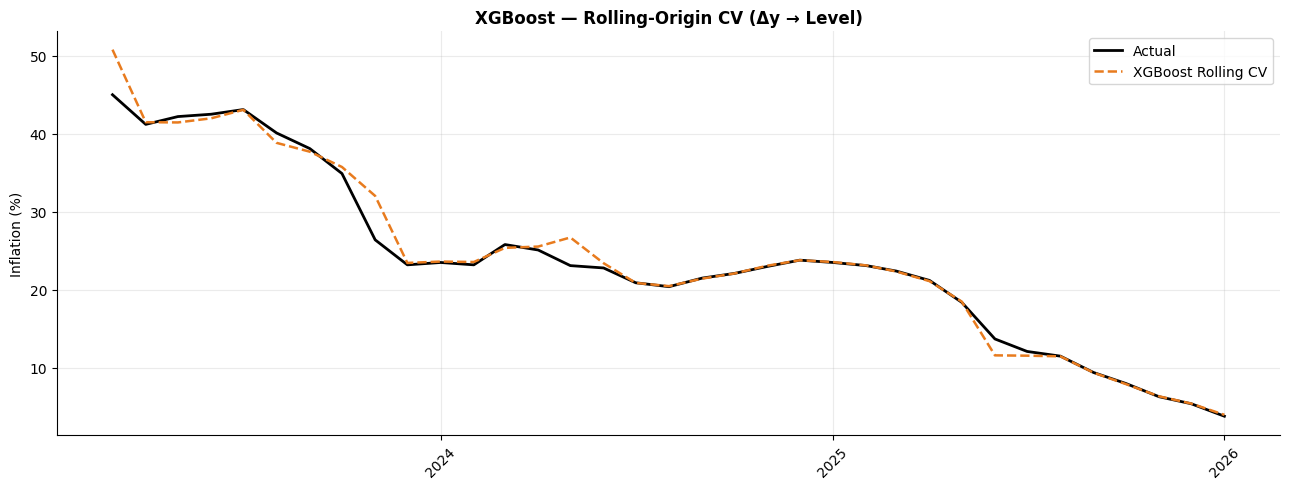


Top 10 features (XGBoost):
diff_2             0.268606
diff_1             0.256470
diff_3             0.165380
inflation_lag1     0.064760
inflation_lag5     0.043304
acceleration       0.041506
inflation_lag4     0.027908
inflation_lag10    0.026866
food_index         0.017966
inflation_lag3     0.015522


In [43]:
# Fit final XGB on full training set for feature importance and test-set forecast
xgb_train = df_xgb.iloc[:-TEST_SIZE].copy()
xgb_test  = df_xgb.iloc[-TEST_SIZE:].copy()

xgb_final = xgb.XGBRegressor(**best_xgb_params, objective='reg:squarederror',
                               random_state=42, verbosity=0)
xgb_final.fit(xgb_train[XGB_FEATURES], xgb_train['delta_y'])

# Recover levels via cumulative sum from last training level (eq 3.5.10)
last_known = xgb_train[TARGET].iloc[-1]
delta_preds = xgb_final.predict(xgb_test[XGB_FEATURES])
xgb_test_pred = []
prev = last_known
for d in delta_preds:
    level = prev + d
    xgb_test_pred.append(level)
    prev = level

xgb_test_res = compute_metrics(xgb_test[TARGET], xgb_test_pred, 'XGBoost Static Test')
all_results.append(xgb_test_res)

# Feature importance via gain (eq 3.5.19)
importance_xgb = pd.Series(
    xgb_final.feature_importances_, index=XGB_FEATURES
).sort_values(ascending=False)

# ── Plot 1: Feature Importance ───────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 7))
ax1.barh(importance_xgb.head(20).index[::-1], importance_xgb.head(20).values[::-1],
         color='#E87B1E', edgecolor='white')
ax1.set_xlabel('Feature Importance (Gain — eq 3.5.19)')
ax1.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for s in ['top', 'right']: ax1.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Rolling-Origin CV ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))
ax2.plot(xgb_cv_dates, xgb_cv_actual, color='black',   linewidth=2,   label='Actual')
ax2.plot(xgb_cv_dates, xgb_cv_pred,   color='#E87B1E', linewidth=1.8,
         linestyle='--', label='XGBoost Rolling CV')
ax2.set_title('XGBoost — Rolling-Origin CV (Δy → Level)', fontweight='bold')
ax2.set_ylabel('Inflation (%)')
ax2.legend()
ax2.grid(alpha=0.25)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
for s in ['top', 'right']: ax2.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'xgb_rolling_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features (XGBoost):')
print(importance_xgb.head(10).to_string())

---
## 6. LSTM
**Section 3.5.4:** Single-layer LSTM, 12 hidden units, dropout=0.5, lookback=6, 10 features.
Adam optimiser, lr=0.001, weight_decay=1e-3, gradient clipping=1.0 (eq 3.5.20–3.5.29).
Monte Carlo Dropout for 95% prediction intervals (eq 3.5.30).
Scalers fit on training data only (eq 3.5.27).

In [44]:
section('LSTM — DATA PREPARATION (Section 3.5.4)')

# Exact architecture from Table 3.4
LOOKBACK   = 6    # Table 3.4
HIDDEN     = 12   # Table 3.4
DROPOUT    = 0.5  # Table 3.4
N_FEATURES = 10   # Table 3.4

# Validate feature count
assert len(LSTM_FEATURES) == N_FEATURES, f'Expected 10 LSTM features, got {len(LSTM_FEATURES)}'

# Split raw arrays (scalers fitted on train only — eq 3.5.27)
X_raw = df[LSTM_FEATURES].values
y_raw = df[TARGET].values.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(X_raw[:-TEST_SIZE])
scaler_y.fit(y_raw[:-TEST_SIZE])

X_scaled = scaler_X.transform(X_raw)
y_scaled = scaler_y.transform(y_raw)

def make_sequences(X, y, lookback):
    """eq 3.5.28 — reshape into (samples, lookback, features)."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, LOOKBACK)

n_train_seq = len(X_seq) - TEST_SIZE
X_train_seq, y_train_seq = X_seq[:n_train_seq], y_seq[:n_train_seq]
X_test_seq,  y_test_seq  = X_seq[n_train_seq:], y_seq[n_train_seq:]

# Validation split: last 20% of training sequences
VAL_SIZE   = max(4, int(n_train_seq * 0.20))
TRAIN_SIZE = n_train_seq - VAL_SIZE

X_tr  = torch.tensor(X_train_seq[:TRAIN_SIZE], dtype=torch.float32)
y_tr  = torch.tensor(y_train_seq[:TRAIN_SIZE], dtype=torch.float32)
X_val = torch.tensor(X_train_seq[TRAIN_SIZE:], dtype=torch.float32)
y_val = torch.tensor(y_train_seq[TRAIN_SIZE:], dtype=torch.float32)
X_te  = torch.tensor(X_test_seq,               dtype=torch.float32)

section('SEQUENCE SPLITS')
print(f"  {'Split':<18} {'Sequences':>12}  {'Shape'}")
print(f"  {'─'*46}")
print(f"  {'Train (fit)':<18} {X_tr.shape[0]:>12}  {tuple(X_tr.shape)}")
print(f"  {'Train (val)':<18} {X_val.shape[0]:>12}  {tuple(X_val.shape)}")
print(f"  {'Test':<18} {X_te.shape[0]:>12}  {tuple(X_te.shape)}")


────────────────────────────────────────────────────────────
  LSTM — DATA PREPARATION (Section 3.5.4)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  SEQUENCE SPLITS
────────────────────────────────────────────────────────────
  Split                 Sequences  Shape
  ──────────────────────────────────────────────
  Train (fit)                 131  (131, 6, 10)
  Train (val)                  32  (32, 6, 10)
  Test                         12  (12, 6, 10)


In [45]:
section('LSTM — MODEL ARCHITECTURE (Table 3.4)')

class SimpleLSTM(nn.Module):
    """Exactly as specified in Table 3.4 and Section 3.5.4."""
    def __init__(self, n_features, hidden=12, dropout=0.5):
        super().__init__()
        # eq 3.5.20 — single-layer LSTM
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True, num_layers=1)
        # dropout=0.5 as in Table 3.4
        self.drop = nn.Dropout(dropout)
        # output layer — single neuron regression (Table 3.4)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))

lstm_model   = SimpleLSTM(N_FEATURES, HIDDEN, DROPOUT)
total_params = sum(p.numel() for p in lstm_model.parameters())

print(f'  Type           : Single-layer LSTM')
print(f'  Input features : {N_FEATURES}  (Table 3.4)')
print(f'  Hidden units   : {HIDDEN}  (Table 3.4)')
print(f'  Dropout        : {DROPOUT}  (Table 3.4)')
print(f'  Lookback       : {LOOKBACK}  (Table 3.4)')
print(f'  Output         : Dense, 1 neuron  (Table 3.4)')
print(f'  Total params   : {total_params:,}')


────────────────────────────────────────────────────────────
  LSTM — MODEL ARCHITECTURE (Table 3.4)
────────────────────────────────────────────────────────────
  Type           : Single-layer LSTM
  Input features : 10  (Table 3.4)
  Hidden units   : 12  (Table 3.4)
  Dropout        : 0.5  (Table 3.4)
  Lookback       : 6  (Table 3.4)
  Output         : Dense, 1 neuron  (Table 3.4)
  Total params   : 1,165



────────────────────────────────────────────────────────────
  LSTM — TRAINING (Section 3.5.4)
────────────────────────────────────────────────────────────
   Epoch     Train MSE       Val MSE          LR
  ──────────────────────────────────────────────
       1      0.182502      0.677425    1.00e-03
      50      0.037513      0.144027    1.00e-03
     100      0.019309      0.101461    2.50e-04
  ──────────────────────────────────────────────
  Early stop : epoch 103  |  best val MSE = 0.090979

  Best weights restored  (val MSE = 0.090979)


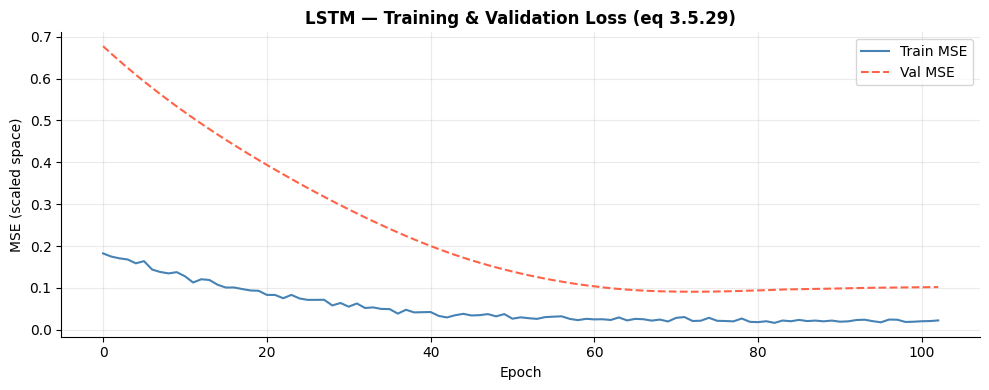

In [46]:
section('LSTM — TRAINING (Section 3.5.4)')

# Adam optimiser, lr=0.001, weight_decay=1e-3 (Section 3.5.4)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
criterion = nn.MSELoss()   # eq 3.5.29

EPOCHS, PATIENCE = 300, 30
best_loss, patience_ctr, best_weights = float('inf'), 0, None
train_losses, val_losses = [], []

print(f"  {'Epoch':>6}  {'Train MSE':>12}  {'Val MSE':>12}  {'LR':>10}")
print(f"  {'─'*46}")

for epoch in range(1, EPOCHS+1):
    lstm_model.train()
    optimizer.zero_grad()
    loss = criterion(lstm_model(X_tr), y_tr)
    loss.backward()
    # Gradient clipping — Section 3.5.4, max norm = 1.0
    nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
    optimizer.step()
    train_losses.append(loss.item())

    lstm_model.eval()
    with torch.no_grad():
        val_loss = criterion(lstm_model(X_val), y_val).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss, patience_ctr = val_loss, 0
        best_weights = {k: v.clone() for k, v in lstm_model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  {'─'*46}")
            print(f"  Early stop : epoch {epoch}  |  best val MSE = {best_loss:.6f}")
            break

    if epoch % 50 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"  {epoch:>6}  {loss.item():>12.6f}  {val_loss:>12.6f}  {lr:>10.2e}")

lstm_model.load_state_dict(best_weights)
print(f'\n  Best weights restored  (val MSE = {best_loss:.6f})')

# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color='steelblue', linewidth=1.5, label='Train MSE')
ax.plot(val_losses,   color='tomato',    linewidth=1.5, linestyle='--', label='Val MSE')
ax.set_title('LSTM — Training & Validation Loss (eq 3.5.29)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled space)')
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────
  LSTM — TEST SET PERFORMANCE
────────────────────────────────────────────────────────────
  LSTM Static Test
  RMSE : 11.6896  (percentage points)
  MAE  : 10.2418  (percentage points)
  MAPE : 138.5919%

  ── Month-by-Month Breakdown
  Month         Actual    Forecast   |Error|
  ──────────────────────────────────────────
  Feb 2025      23.10%      24.07%     0.97pp
  Mar 2025      22.40%      24.11%     1.71pp
  Apr 2025      21.20%      24.15%     2.95pp
  May 2025      18.40%      24.19%     5.79pp
  Jun 2025      13.70%      24.16%    10.46pp
  Jul 2025      12.10%      23.90%    11.80pp
  Aug 2025      11.50%      23.43%    11.93pp
  Sep 2025       9.40%      22.98%    13.58pp
  Oct 2025       8.00%      22.59%    14.59pp
  Nov 2025       6.30%      22.12%    15.82pp
  Dec 2025       5.40%      21.58%    16.18pp
  Jan 2026       3.80%      20.93%    17.13pp


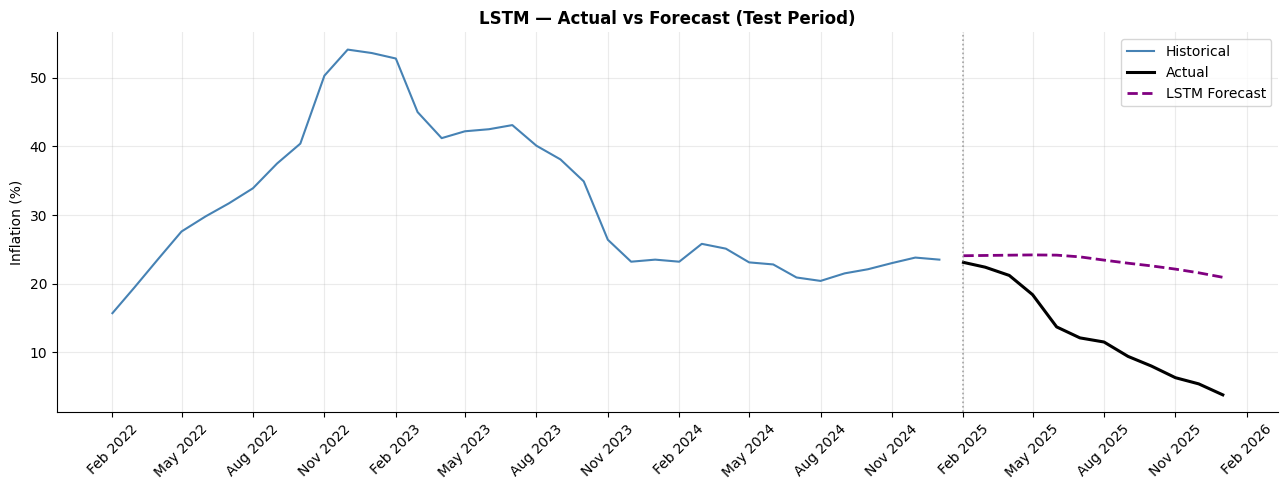

In [47]:
section('LSTM — TEST SET PERFORMANCE')

lstm_model.eval()
with torch.no_grad():
    pred_scaled = lstm_model(X_te).numpy()

# Inverse MinMax transform (eq 3.5.27 inverse)
lstm_pred   = scaler_y.inverse_transform(pred_scaled).flatten()
y_test_true = scaler_y.inverse_transform(y_test_seq).flatten()
test_dates  = df.index[-TEST_SIZE:]

lstm_test_res = compute_metrics(y_test_true, lstm_pred, 'LSTM Static Test')
all_results.append(lstm_test_res)

subsection('Month-by-Month Breakdown')
print(f"  {'Month':<10}  {'Actual':>8}  {'Forecast':>10}  {'|Error|':>8}")
print(f"  {'─'*42}")
for i, (a, p) in enumerate(zip(y_test_true, lstm_pred)):
    print(f"  {test_dates[i].strftime('%b %Y'):<10}  {a:>7.2f}%  {p:>9.2f}%  {abs(a-p):>7.2f}pp")

# Forecast plot
fig, ax = plt.subplots(figsize=(13, 5))
train_ctx = df[TARGET].iloc[-TEST_SIZE-36:-TEST_SIZE]
ax.plot(train_ctx.index, train_ctx.values, color='steelblue', linewidth=1.5, label='Historical')
ax.plot(test_dates, y_test_true,           color='black',     linewidth=2.2, label='Actual')
ax.plot(test_dates, lstm_pred,             color='purple',    linewidth=2, linestyle='--', label='LSTM Forecast')
ax.axvline(test_dates[0], color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_title('LSTM — Actual vs Forecast (Test Period)', fontweight='bold')
ax.set_ylabel('Inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
#plt.savefig(SAVE_PATH + 'lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────
  LSTM — ROLLING-ORIGIN CROSS-VALIDATION
────────────────────────────────────────────────────────────
  Step  1 (Jan 2023): Actual= 53.60  Pred= 36.91
  Step  5 (May 2023): Actual= 42.20  Pred= 42.69
  Step 10 (Oct 2023): Actual= 34.90  Pred= 40.61
  Step 15 (Mar 2024): Actual= 25.80  Pred= 33.28
  Step 20 (Aug 2024): Actual= 20.40  Pred= 24.30
  Step 25 (Jan 2025): Actual= 23.50  Pred= 20.77
  Step 30 (Jun 2025): Actual= 13.70  Pred= 21.73
  Step 35 (Nov 2025): Actual=  6.30  Pred= 17.70
  LSTM (Rolling CV)
  RMSE : 7.7995  (percentage points)
  MAE  : 6.3411  (percentage points)
  MAPE : 41.4000%


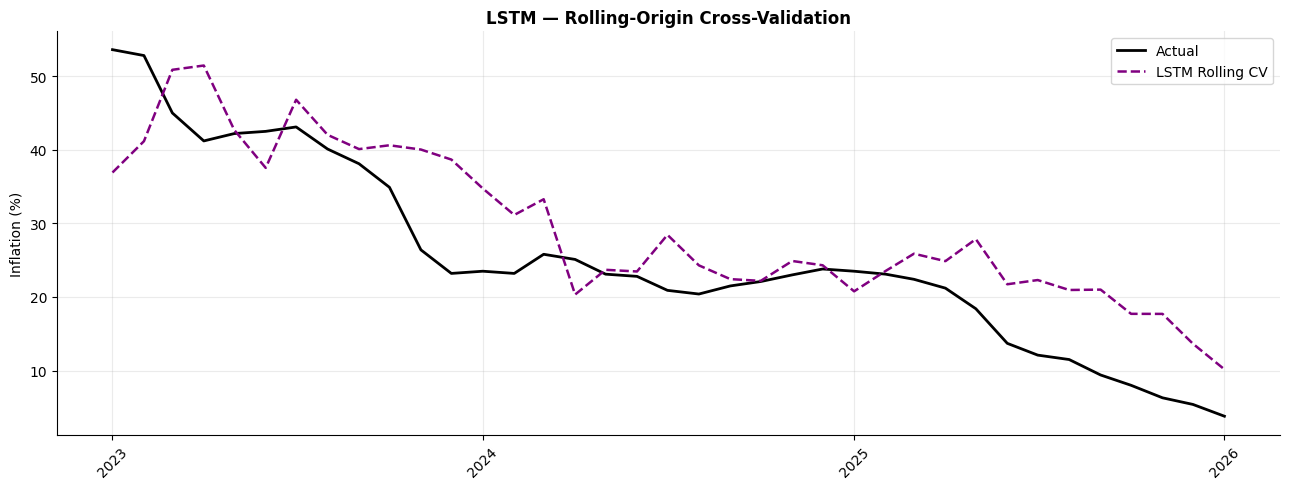

In [48]:
section('LSTM — ROLLING-ORIGIN CROSS-VALIDATION')

CV_EPOCHS = 150
lstm_cv_actual, lstm_cv_pred, lstm_cv_dates = [], [], []

for i in range(MIN_TRAIN, len(df)):
    sx = MinMaxScaler(); sy = MinMaxScaler()
    sx.fit(X_raw[:i]); sy.fit(y_raw[:i])
    X_i = sx.transform(X_raw[:i+1])
    y_i = sy.transform(y_raw[:i+1])
    Xs, ys = make_sequences(X_i, y_i, LOOKBACK)
    if len(Xs) < LOOKBACK + 2:
        continue

    X_cv_t = torch.tensor(Xs[:-1], dtype=torch.float32)
    y_cv_t = torch.tensor(ys[:-1], dtype=torch.float32)

    # Re-initialise same architecture for each step
    cv_model = SimpleLSTM(N_FEATURES, HIDDEN, DROPOUT)
    cv_opt   = torch.optim.Adam(cv_model.parameters(), lr=1e-3, weight_decay=1e-3)
    cv_crit  = nn.MSELoss()
    best_cv_loss, best_cv_w = float('inf'), None

    cv_model.train()
    for ep in range(CV_EPOCHS):
        cv_opt.zero_grad()
        l = cv_crit(cv_model(X_cv_t), y_cv_t)
        l.backward()
        nn.utils.clip_grad_norm_(cv_model.parameters(), 1.0)
        cv_opt.step()
        if l.item() < best_cv_loss:
            best_cv_loss = l.item()
            best_cv_w = {k: v.clone() for k, v in cv_model.state_dict().items()}

    cv_model.load_state_dict(best_cv_w)
    cv_model.eval()
    with torch.no_grad():
        p_sc = cv_model(torch.tensor(Xs[-1:], dtype=torch.float32)).numpy()

    pred_val = sy.inverse_transform(p_sc).flatten()[0]
    true_val = y_raw[i][0]
    lstm_cv_actual.append(true_val)
    lstm_cv_pred.append(pred_val)
    lstm_cv_dates.append(df.index[i])

    step = i - MIN_TRAIN + 1
    if step % 5 == 0 or step == 1:
        print(f'  Step {step:>2d} ({df.index[i].strftime("%b %Y")}): '
              f'Actual={true_val:6.2f}  Pred={pred_val:6.2f}')

lstm_cv_res = compute_metrics(lstm_cv_actual, lstm_cv_pred, 'LSTM (Rolling CV)')
all_results.append(lstm_cv_res)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(lstm_cv_dates, lstm_cv_actual, color='black',  linewidth=2, label='Actual')
ax.plot(lstm_cv_dates, lstm_cv_pred,   color='purple', linewidth=1.8, linestyle='--', label='LSTM Rolling CV')
ax.set_title('LSTM — Rolling-Origin Cross-Validation', fontweight='bold')
ax.set_ylabel('Inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'lstm_rolling_cv.png', dpi=150, bbox_inches='tight')
plt.show()


────────────────────────────────────────────────────────────
  LSTM — MONTE CARLO DROPOUT PREDICTION INTERVALS (eq 3.5.30)
────────────────────────────────────────────────────────────
  Month         Actual      Mean    Lower 95    Upper 95   In CI?
  ──────────────────────────────────────────────────────────────
  Feb 2025      23.10%    22.90%       1.50%      43.28%        ✓
  Mar 2025      22.40%    24.33%       2.73%      44.79%        ✓
  Apr 2025      21.20%    24.62%       2.37%      45.26%        ✓
  May 2025      18.40%    23.87%       1.93%      44.83%        ✓
  Jun 2025      13.70%    24.17%       2.06%      45.23%        ✓
  Jul 2025      12.10%    24.39%       4.09%      45.84%        ✓
  Aug 2025      11.50%    22.73%       1.21%      45.05%        ✓
  Sep 2025       9.40%    23.23%       3.09%      43.86%        ✓
  Oct 2025       8.00%    22.39%       3.36%      43.16%        ✓
  Nov 2025       6.30%    22.35%       2.79%      41.71%        ✓
  Dec 2025       5.40%  

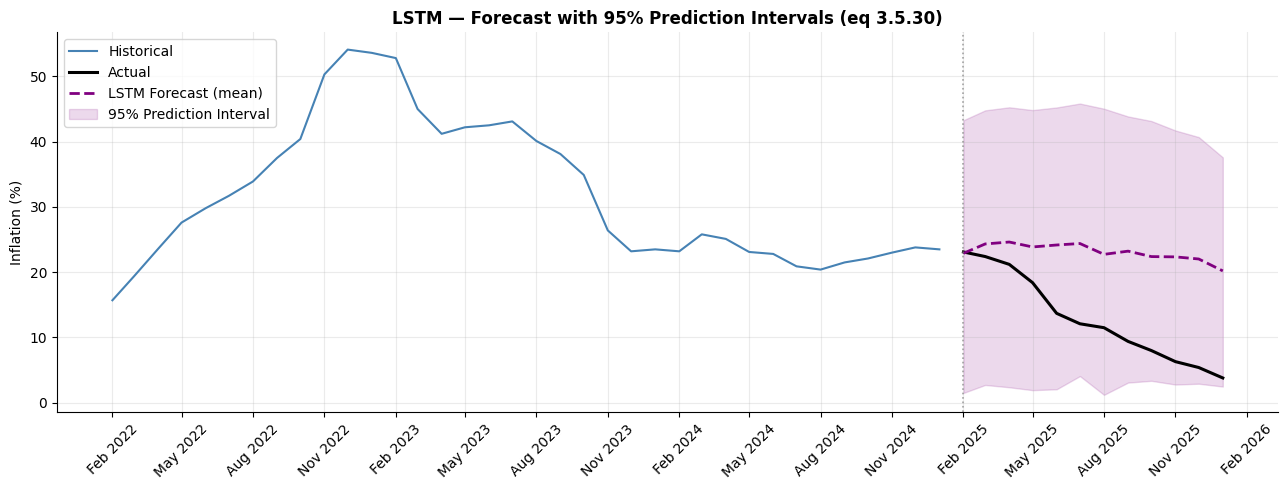

In [49]:
section('LSTM — MONTE CARLO DROPOUT PREDICTION INTERVALS (eq 3.5.30)')

N_SAMPLES = 500
lstm_model.train()   # keep dropout active for MC sampling
mc_preds = []
with torch.no_grad():
    for _ in range(N_SAMPLES):
        p = scaler_y.inverse_transform(lstm_model(X_te).numpy()).flatten()
        mc_preds.append(p)

mc_preds  = np.array(mc_preds)
mc_mean   = mc_preds.mean(axis=0)
mc_lower  = np.percentile(mc_preds,  2.5, axis=0)   # eq 3.5.30
mc_upper  = np.percentile(mc_preds, 97.5, axis=0)   # eq 3.5.30
coverage  = np.mean((y_test_true >= mc_lower) & (y_test_true <= mc_upper)) * 100

print(f"  {'Month':<10}  {'Actual':>8}  {'Mean':>8}  {'Lower 95':>10}  {'Upper 95':>10}  {'In CI?':>7}")
print(f"  {'─'*62}")
for i, (a, m, lo, hi) in enumerate(zip(y_test_true, mc_mean, mc_lower, mc_upper)):
    flag = '✓' if lo <= a <= hi else '✗'
    print(f"  {test_dates[i].strftime('%b %Y'):<10}  {a:>7.2f}%  {m:>7.2f}%  "
          f"{lo:>9.2f}%  {hi:>9.2f}%  {flag:>7}")

print(f"\n  Empirical coverage : {coverage:.1f}%  (nominal 95%)")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_ctx.index, train_ctx.values, color='steelblue', linewidth=1.5, label='Historical')
ax.plot(test_dates, y_test_true,           color='black',     linewidth=2.2, label='Actual')
ax.plot(test_dates, mc_mean,               color='purple',    linewidth=2, linestyle='--', label='LSTM Forecast (mean)')
ax.fill_between(test_dates, mc_lower, mc_upper, color='purple', alpha=0.15, label='95% Prediction Interval')
ax.axvline(test_dates[0], color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_title('LSTM — Forecast with 95% Prediction Intervals (eq 3.5.30)', fontweight='bold')
ax.set_ylabel('Inflation (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
#plt.savefig(SAVE_PATH + 'lstm_prediction_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model Comparison (Section 4.6)
Full comparison table, overlay chart, error-over-time plot, RF vs XGBoost feature importance.

In [50]:
section('FINAL MODEL COMPARISON — ALL METRICS')

results_df = pd.DataFrame(all_results)

# Separate rolling CV from static test
rolling_df = results_df[results_df['Model'].str.contains('Rolling CV')].sort_values('RMSE').reset_index(drop=True)
static_df  = results_df[~results_df['Model'].str.contains('Rolling CV')].sort_values('RMSE').reset_index(drop=True)

print('\n=== Rolling-Origin Cross-Validation Results ===')
print(rolling_df.to_string(index=False))

print('\n=== Static 12-Month Test-Set Results ===')
print(static_df.to_string(index=False))

# Save to CSV for dissertation appendix
results_df.to_csv(SAVE_PATH + 'model_results_summary.csv', index=False)
print('\nSaved: model_results_summary.csv')


────────────────────────────────────────────────────────────
  FINAL MODEL COMPARISON — ALL METRICS
────────────────────────────────────────────────────────────

=== Rolling-Origin Cross-Validation Results ===
                     Model   RMSE    MAE    MAPE
      XGBoost (Rolling CV) 1.5780 0.7119  2.8373
      SARIMAX (Rolling CV) 3.1355 2.5746 12.6087
Random Forest (Rolling CV) 4.3791 3.3448 16.2494
         LSTM (Rolling CV) 7.7995 6.3411 41.4000

=== Static 12-Month Test-Set Results ===
                    Model    RMSE     MAE     MAPE
      XGBoost Static Test  2.3105  1.8988  25.4610
Random Forest Static Test  3.7649  3.1485  37.5864
      SARIMAX Static Test  5.5719  4.8459  65.6978
         LSTM Static Test 11.6896 10.2418 138.5919

Saved: model_results_summary.csv



────────────────────────────────────────────────────────────
  ALL MODELS VS ACTUAL — OVERLAY (Figure for Section 4.6)
────────────────────────────────────────────────────────────


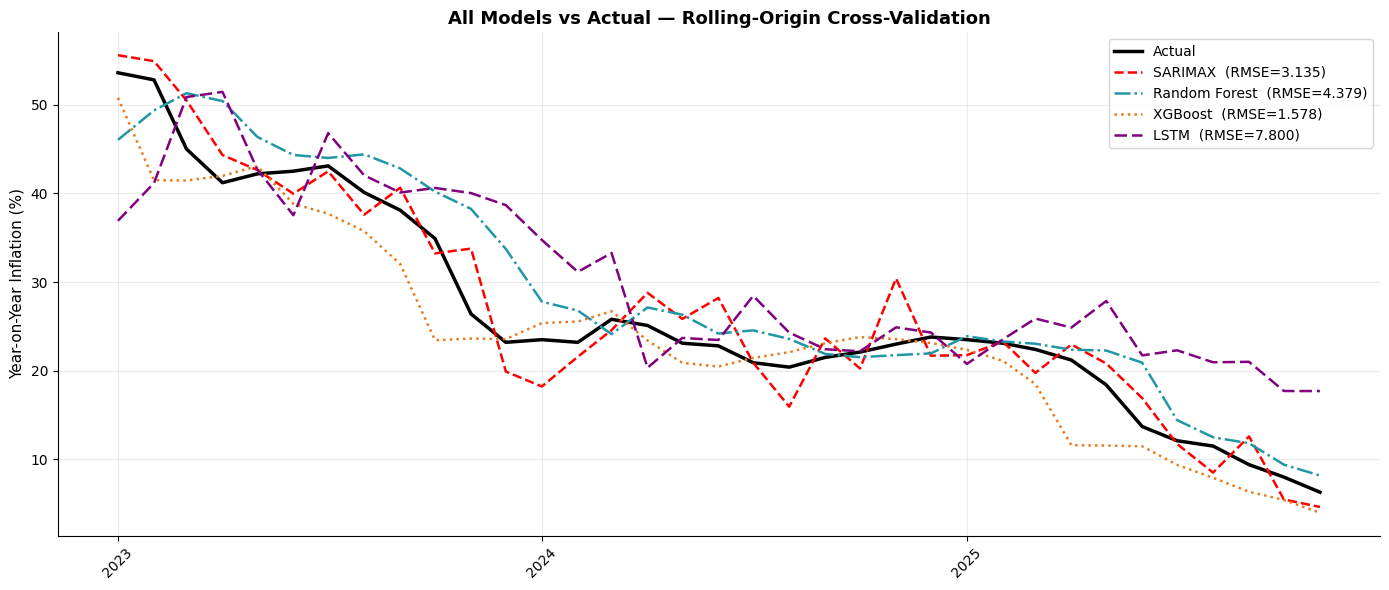

In [51]:
# All models vs actual — single overlay chart
section('ALL MODELS VS ACTUAL — OVERLAY (Figure for Section 4.6)')

# Align all rolling CV series to the same date index
n_steps = min(len(sarimax_cv_actual), len(rf_cv_actual),
              len(xgb_cv_actual),      len(lstm_cv_actual))
dates_all = df.index[MIN_TRAIN:MIN_TRAIN + n_steps]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_all, sarimax_cv_actual[:n_steps], color='black',     linewidth=2.5,  label='Actual')
ax.plot(dates_all, sarimax_cv_pred[:n_steps],   color='red',       linewidth=1.8, linestyle='--',
        label=f'SARIMAX  (RMSE={sarimax_cv_res["RMSE"]:.3f})')
ax.plot(dates_all, rf_cv_pred[:n_steps],         color='#2196A6',   linewidth=1.8, linestyle='-.',
        label=f'Random Forest  (RMSE={rf_cv_res["RMSE"]:.3f})')
ax.plot(dates_all, xgb_cv_pred[:n_steps],        color='#E87B1E',   linewidth=1.8, linestyle=':',
        label=f'XGBoost  (RMSE={xgb_cv_res["RMSE"]:.3f})')
ax.plot(dates_all, lstm_cv_pred[:n_steps],        color='purple',    linewidth=1.8,
        linestyle=(0,(5,2)), label=f'LSTM  (RMSE={lstm_cv_res["RMSE"]:.3f})')

ax.set_title('All Models vs Actual — Rolling-Origin Cross-Validation', fontsize=13, fontweight='bold')
ax.set_ylabel('Year-on-Year Inflation (%)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
#plt.savefig(SAVE_PATH + 'all_models_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

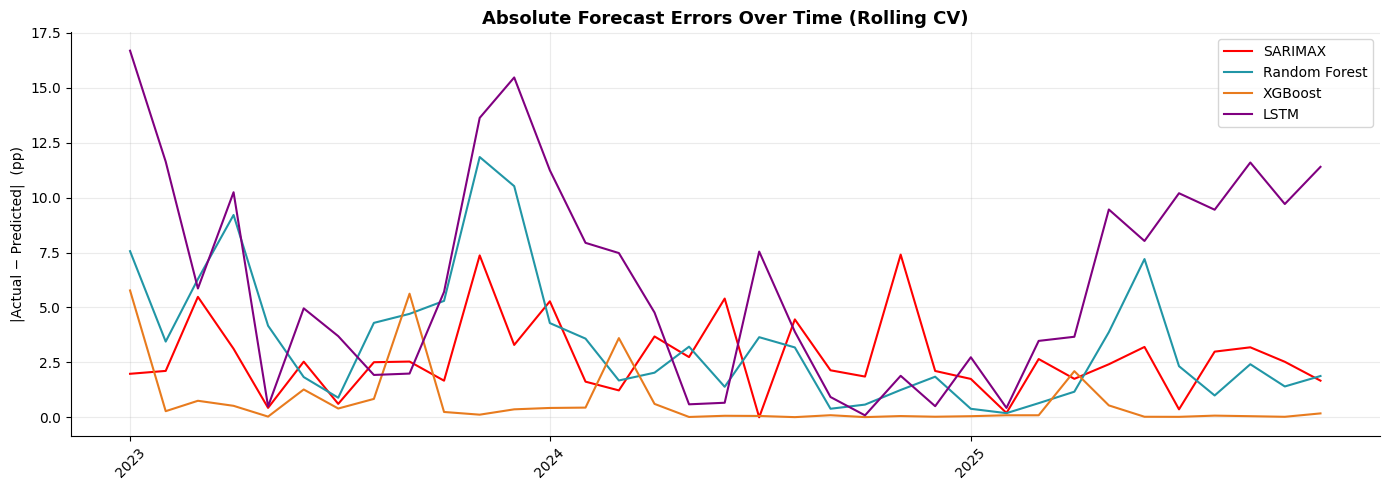

In [52]:
# Absolute error over time — reveals which model struggled most in 2022-2025
errors_df = pd.DataFrame({
    'SARIMAX':      np.abs(np.array(sarimax_cv_pred[:n_steps]) - np.array(sarimax_cv_actual[:n_steps])),
    'Random Forest':np.abs(np.array(rf_cv_pred[:n_steps])      - np.array(rf_cv_actual[:n_steps])),
    'XGBoost':      np.abs(np.array(xgb_cv_pred[:n_steps])     - np.array(xgb_cv_actual[:n_steps])),
    'LSTM':         np.abs(np.array(lstm_cv_pred[:n_steps])     - np.array(lstm_cv_actual[:n_steps])),
}, index=dates_all)

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(errors_df.columns, ['red','#2196A6','#E87B1E','purple']):
    ax.plot(errors_df.index, errors_df[col], color=color, linewidth=1.5, label=col)
ax.set_title('Absolute Forecast Errors Over Time (Rolling CV)', fontsize=13, fontweight='bold')
ax.set_ylabel('|Actual − Predicted|  (pp)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'error_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

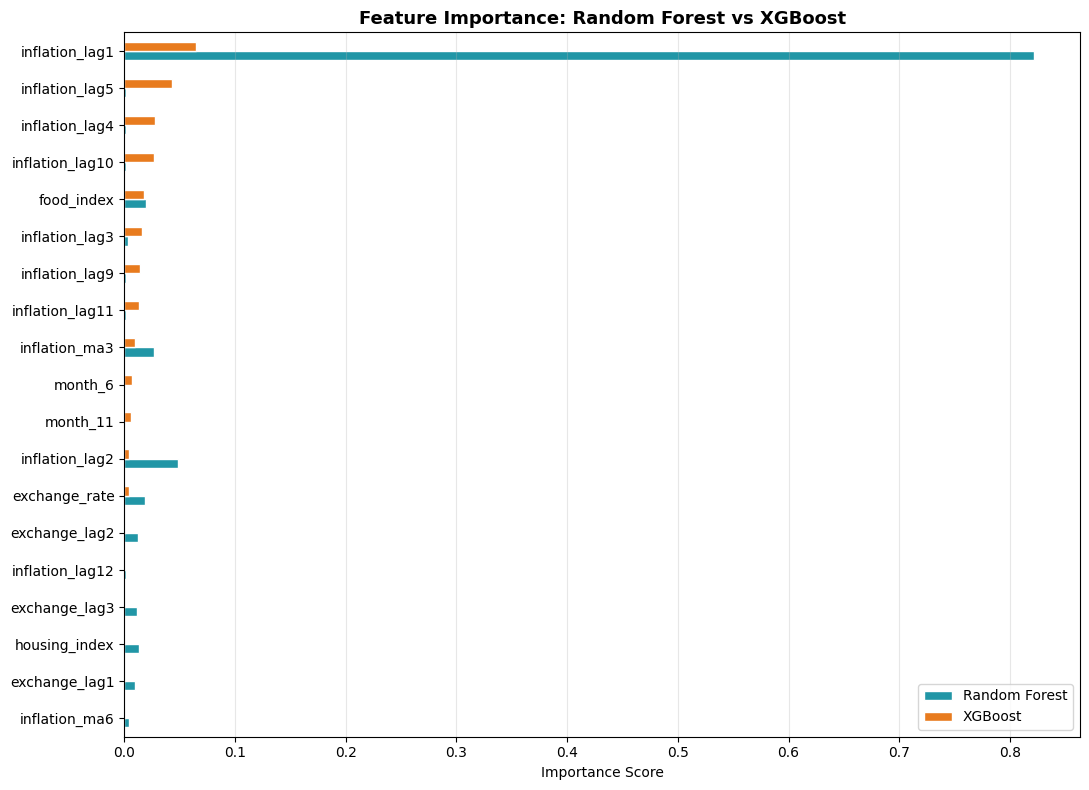


Done. All outputs saved.


In [53]:
# RF vs XGBoost feature importance comparison
top_feats = list(set(
    list(importance_rf.head(15).index) +
    list(importance_xgb.head(15).index)
))
# Only compare features present in both
common = [f for f in top_feats if f in importance_rf.index and f in importance_xgb.index]
compare_df = pd.DataFrame({
    'Random Forest': importance_rf[common],
    'XGBoost':       importance_xgb[common]
}).dropna().sort_values('XGBoost', ascending=True)

compare_df.plot(kind='barh', figsize=(11, 8), color=['#2196A6','#E87B1E'], edgecolor='white')
plt.title('Feature Importance: Random Forest vs XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDone. All outputs saved.')